## Heave Prediction Algorithm

This notebook contains code for predicting future heave states of a moving ship.
LSTM model is used popularly for this task and below is an implementation of the same.

Refer the below link for more details:

https://studenttheses.uu.nl/bitstream/handle/20.500.12932/43977/Master%20Thesis%20-%20Jolan%20Keijzer%20-%20Ship%20Heave%20Motion%20Prediction%20Using%20LSTM%20Neural%20Networks%20Without%20Wave%20Excitation%20Information.pdf?sequence=1


https://medium.com/@rebeen.jaff/what-is-lstm-introduction-to-long-short-term-memory-66bd3855b9ce

### vanillaRNN vs GRUs vs LSTM vs bi-directional LSTM

### Test single feature vs multiple feature, old vs new data

### Note that data is better when a bit streched uniformly and not stretched by extremes touching. remove outliers and then train.

### You are normalising only wrt to Z and not whole feature space like Vz,a_z. Note that too

### Preprocessing

## BETTER THE DATA ACQUISITION RATE, BETTER THE CODE RUN. CURRENTLY IT IS 20Hz

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Calculating normalised heave. Note I dont need other params than Z,Vz,a_z as possibly I might not have them in realtime.
# I would have thetas & dthetas though. but let see

sampling_rate = 20
# scaler = MinMaxScaler(feature_range=(0, 1))
df = pd.read_csv("/content/D1H5Z_scaled_10hz.csv")
Z = df['Z']
X = np.arange(0, len(df['Z'])/20,0.05)
df = df[(df['Z'] > -10.0) & (df['Z'] < 10.0)]

scaler_custom = MinMaxScaler(feature_range=(-1, 1))
df['Z_normalized'] = scaler_custom.fit_transform(df['Z'].values.reshape(-1, 1))

print(df.head())
# Calculating Vz, a_z from this new normalised Z signal.
# Calculate the time step
dt = 1 / sampling_rate

# Calculate the first derivative (differential)
Vz = np.gradient(df['Z_normalized'].values, dt)

# Calculate the second derivative (double derivative)
a_z = np.gradient(Vz, dt)

df['Vz_'] = Vz
df['a_z_'] = a_z

print(df.tail())

FileNotFoundError: [Errno 2] No such file or directory: '/content/D1H5Z_scaled_10hz.csv'

### Heave Plots

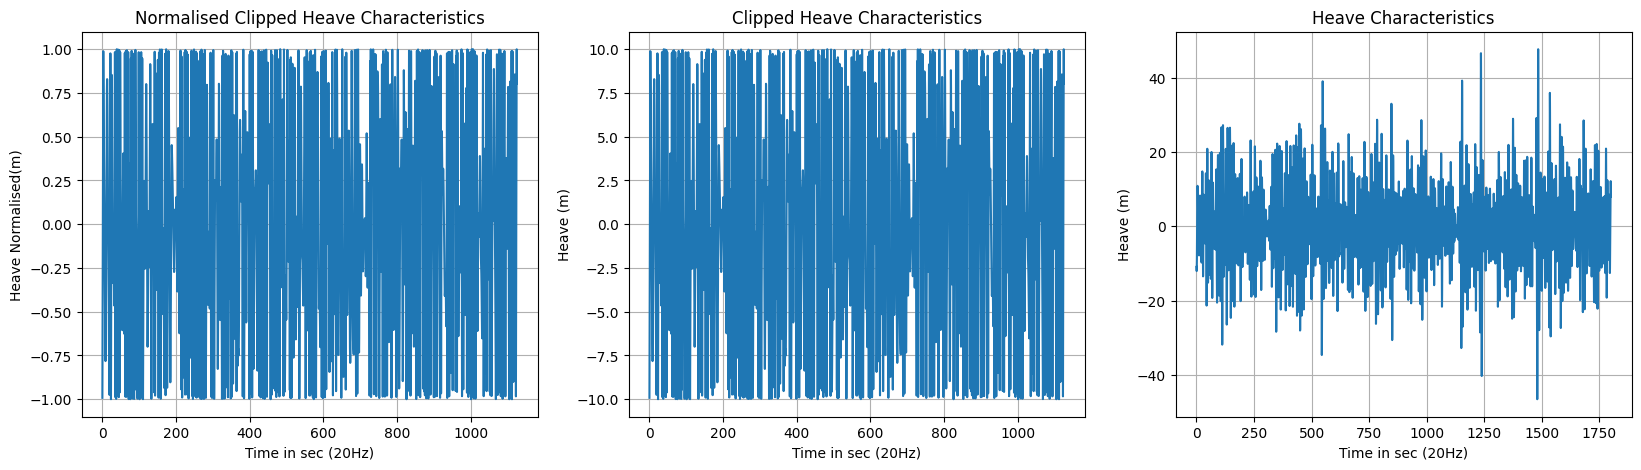

In [ ]:
# Create two plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

x = np.arange(0, len(df['Z'])/20,0.05)
y = df['Z_normalized']

ax1.plot(x, y)
ax1.set_xlabel("Time in sec (20Hz)")
ax1.set_ylabel("Heave Normalised(m)")
ax1.set_title("Normalised Clipped Heave Characteristics")
ax1.grid()

ax2.plot(x, df['Z'])
ax2.set_xlabel("Time in sec (20Hz)")
ax2.set_ylabel("Heave (m)")
ax2.set_title("Clipped Heave Characteristics")
ax2.grid()

ax3.plot(X, Z)
ax3.set_xlabel("Time in sec (20Hz)")
ax3.set_ylabel("Heave (m)")
ax3.set_title("Heave Characteristics")
ax3.grid()

plt.show()

### Import libraries

In [ ]:
# !pip install tensorflow==1.14.0
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

2.17.0
Num GPUs Available:  0


### Define model parameters

In [ ]:
# Define the parameters
num_layers = 4  # Optimal number of layers, can vary between 1 and 6
start_units = 64
units_per_layer = 64  # Optimal units per layer, can vary between 16 and 512
learning_rate = 1e-4  # Optimal learning rate, can be one of [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
batch_size = 256  # Optimal batch size, can vary between 64 and 1024
dropout_rate = 0.3  # Dropout rate, can vary between 0 and 0.5
optimizer_choice = 'adam'  # Choice between 'adam' and 'sgd'
early_stop_patience = 10  # Early stopping patience for validation loss
timesteps=75
features=3
# SEQ_LENGTH = 150  # Example sequence length
N_STEPS = 20    # Number of future steps to predict

### Model Architecture

In [ ]:
model = Sequential()

# Adding LSTM layers with dropout
for i in range(num_layers):
    if i == 0:
        model.add(LSTM(units=start_units, return_sequences=True, input_shape=(timesteps, features), dtype='float16'))
        # model.add(Dropout(dropout_rate))
    elif i == num_layers - 1:
        model.add(LSTM(units=units_per_layer, dtype='float16'))
    else:
        model.add(LSTM(units=units_per_layer, return_sequences=True, dtype='float16'))
    model.add(Dropout(dropout_rate))

# Adding a Dense layer with linear activation
model.add(Dense(N_STEPS, activation='linear', dtype='float16'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Compilation

In [ ]:
if optimizer_choice == 'adam':
    optimizer = Adam(learning_rate=learning_rate)
else:
    optimizer = SGD(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=early_stop_patience, restore_best_weights=True)

### Model Summary

In [ ]:
# The main aim is to lower the Trainable params number so training/prediction is faster
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 75, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 75, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 75, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 75, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 75, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │           1,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,780 (230.04 KB)

 Trainable params: 117,780 (230.04 KB)

 Non-trainable params: 0 (0.00 B)

## Dataset Preprocessing

1. Load the Data: Load the data from your files.

2. Normalize the Data: Normalize the Z(m) values to a range that LSTMs can handle better, typically between 0 and 1 or -1 and 1.

3. Create Sequences: Convert the data into sequences that LSTM can use for training.

4. Split into Train and Test Sets: Divide your data into training and validation sets.

5. Reshape the Data: Ensure the data is in the shape (samples, timesteps, features) for the LSTM.

### Deciding Sequence Length

In [ ]:
x = df.loc[0:10-1, ['Z_normalized', 'Vz_','a_z_']].values
y = df.loc[1:11-1, ['Z_normalized', 'Vz_','a_z_']].values
x = np.stack((x, y), axis=0)
y = np.expand_dims(y, axis=0)
x = np.concatenate((x, y), axis=0)
print(x)
print(x.shape)

[]
(3, 0, 3)


In [ ]:
# Load np array
# X_train = np.load('X_train.npy')
# X_val = np.load('/content/X_val_d1h4.npy')
# y_train = np.load('y_train.npy')
# y_val = np.load('y_val.npy')

In [ ]:
from sklearn.model_selection import train_test_split

def create_sequences_with_ground_truth(df_, seq_length, n_steps):
    shapex = (seq_length, 3)
    shapey = (n_steps, 1)
    xs = np.zeros(shape=shapex)
    ys = np.zeros(shape=shapey)
    for i in range(0,len(df_['Z']) - seq_length - n_steps):
        low=i
        upper=i+seq_length
        x = df_.loc[low:upper-1, ['Z_normalized', 'Vz_','a_z_']].values
        y = df_.loc[upper:upper+n_steps-1, ['Z_normalized']].values
        if i==0:
          xs = x
          xs = np.expand_dims(xs, axis=0)
          ys = y
          ys = np.expand_dims(ys, axis=0)
        else:
          x = np.expand_dims(x, axis=0)
          xs = np.concatenate((xs, x), axis=0)
          y = np.expand_dims(y, axis=0)
          ys = np.concatenate((ys, y), axis=0)
    return np.array(xs), np.array(ys)

df=df.dropna()
df=df.reset_index(drop=True)

# Create sequences and corresponding ground truth future values df['Z_normalized'].values
X_input, y_input = create_sequences_with_ground_truth(df, timesteps, N_STEPS)
print("X_train Shape:",X_input.shape)
print("Y_train Shape:",y_input.shape)
# Split into train and test sets
X_train, X_val, y_train, y_val = train_test_split(X_input, y_input, test_size=0.2, shuffle=False)

# Reshape X to be 3D
# Reshape the data to fit the LSTM model's expected input shape (samples, timesteps, features):
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], features))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 3))
print("X_val Shape:",X_val.shape)
print("Y_val Shape:",y_val.shape)

X_train Shape: (22419, 75, 3)
Y_train Shape: (22419, 20, 1)
X_val Shape: (4484, 75, 3)
Y_val Shape: (4484, 20, 1)


### Save and load array

In [ ]:
np.save('X_train_d1h4', X_train)
np.save('X_val_d1h4', X_val)
np.save('y_train_d1h4', y_train)
np.save('y_val_d1h4', y_val)

In [ ]:
# np.savetxt('X_train_d1h4.csv', X_train)
# np.savetxt('X_val_d1h4.csv', X_val)
# np.savetxt('y_train_d1h4.csv', y_train)
# np.savetxt('y_val_d1h4.csv', y_val)

### Model Testing

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.1976 - val_loss: 0.0743
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0913 - val_loss: 0.0899
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0752 - val_loss: 0.0463
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0588 - val_loss: 0.0777
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - loss: 0.0587 - val_loss: 0.0353
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - loss: 0.0473 - val_loss: 0.0193
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - loss: 0.0417 - val_loss: 0.0178
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - loss: 0.0402 - val_loss: 0.0327
Epoch 9/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 0.0451 - val_loss: 0.0173
Epoch 10/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - loss: 0.0369 - val_loss: 0.0172
Epoch 11/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - loss: 0.0357 - val_loss: 0.1270
Epoch 12/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: nan

### Save the model

In [ ]:
# Save the model
model.save('model_iteration7_.h5')

## Integration with TRT

### Import the necessary libraries

In [ ]:
#!pip install nvidia-tensorrt
# !pip install tensorflow-tensorrt
import tensorflow.experimental.tensorrt as trt
import tensorflow_model_optimization as tfmot

ERROR: Could not find a version that satisfies the requirement tensorflow-tensorrt (from versions: none)
ERROR: No matching distribution found for tensorflow-tensorrt


### Model Loading

In [ ]:
# Load the HDF5 model
model = tf.keras.models.load_model('model_iteration2.h5')

# Save it in the SavedModel format
model.save('model_iteration2')

# Now, convert to TensorRT optimized model
conversion_params = trt.ConversionParams(precision_mode='FP16')
converter = trt.Converter(input_saved_model_dir='model_iteration2', conversion_params=conversion_params)

converter.convert()
converter.save('model_iteration2_TRT')

### Running Inference

In [ ]:
# Load the TensorRT optimized model
saved_model_loaded = tf.saved_model.load('model_iteration2_TRT', tags=[tf.saved_model.SERVING])
infer = saved_model_loaded.signatures['serving_default']

# Run inference
input_data = X_train_d1h4
output = infer(tf.constant(input_data))

## Model Enhancement

In [ ]:
quantize_model = tfmot.quantization.keras.quantize_model

# Quantize the model
q_aware_model = quantize_model(model)
q_aware_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fine-tune the quantized model
q_aware_model.fit(train_dataset, epochs=1, validation_data=val_dataset)

# Save the quantized model
q_aware_model.save('model_iteration2_TRT_quantized')

In [ ]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

# Define the pruning parameters
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50,
                                                             final_sparsity=0.80,
                                                             begin_step=2000,
                                                             end_step=4000)}

# Apply pruning to the model
pruned_model = prune_low_magnitude(model, **pruning_params)
pruned_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fine-tune the pruned model
pruned_model.fit(train_dataset, epochs=1, validation_data=val_dataset)

# Strip the pruning wrappers and save the pruned model
model_for_export = tfmot.sparsity.keras.strip_pruning(pruned_model)
model_for_export.save('model_iteration2_TRT_pruned')

In [ ]:
# Define the teacher model (already trained)
teacher_model = tf.keras.models.load_model('path_to_teacher_model')

# Define the student model (smaller model)
student_model = tf.keras.Sequential([...])

# Define a custom training loop for knowledge distillation
def distillation_loss(y_true, y_pred, teacher_logits):
    alpha = 0.1  # weight for the distillation loss
    temperature = 10.0
    distillation_loss = tf.keras.losses.KLDivergence()(
        tf.nn.softmax(teacher_logits / temperature, axis=1),
        tf.nn.softmax(y_pred / temperature, axis=1)
    )
    return alpha * distillation_loss + (1. - alpha) * tf.keras.losses.CategoricalCrossentropy()(y_true, y_pred)

student_model.compile(optimizer='adam', loss=distillation_loss, metrics=['accuracy'])

# Train the student model using the teacher model's predictions
student_model.fit(train_dataset, epochs=1, validation_data=val_dataset)

# Model.predict()

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_val)

141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step


### Plot The Metrics

[[-0.52071166 -0.46842747 -0.41414313 ... -0.11660933 -0.05271722
   0.01230998]
 [-0.46842747 -0.41414313 -0.35796864 ... -0.05271722  0.01230998
   0.07833527]
 [-0.41414313 -0.35796864 -0.300014   ...  0.01230998  0.07833527
   0.14521162]
 ...
 [ 0.81239499  0.85269822  0.8912413  ...  0.9700176   0.93906513
   0.90673254]
 [ 0.85269822  0.8912413   0.92795424 ...  0.93906513  0.90673254
   0.87308985]
 [ 0.8912413   0.92795424  0.96274702 ...  0.90673254  0.87308985
   0.83824706]]
---
[[-0.528   -0.4011  -0.3997  ... -0.1681  -0.1649  -0.1349 ]
 [-0.482   -0.343   -0.3396  ... -0.0947  -0.1059  -0.06464]
 [-0.4297  -0.279   -0.2744  ... -0.0163  -0.0363   0.0165 ]
 ...
 [ 0.7944   0.855    0.825   ...  0.941    0.902    0.863  ]
 [ 0.8193   0.8794   0.8447  ...  0.9683   0.914    0.891  ]
 [ 0.841    0.902    0.864   ...  0.9937   0.924    0.918  ]]
---
(4486, 10)


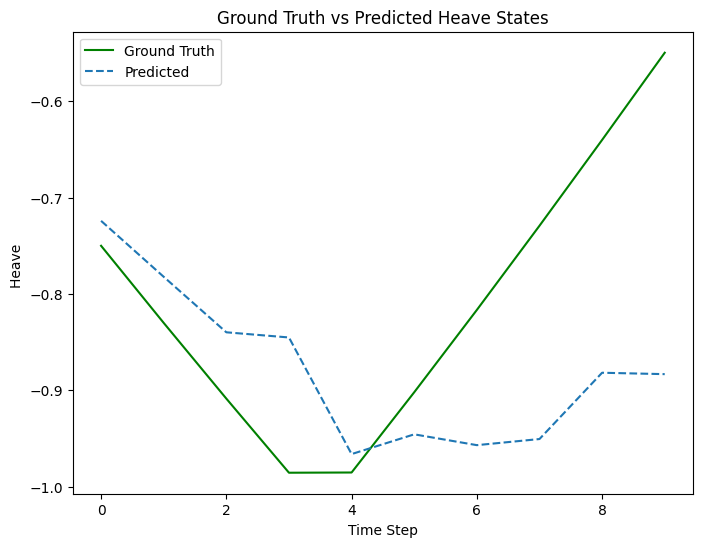

In [ ]:
y_val = y_val.reshape(-1,10)
y_pred = y_pred.reshape(-1,10)
print(y_val)
print("---")
print(y_pred)
print("---")
print(y_pred.shape)
# accuracy = accuracy_score(y_val, y_pred)
# accuracy_percentage = accuracy * 100
# print(f"Accuracy on validation set: {accuracy_percentage:.2f}%")

# Plotting Graphs

# Plot the first example from the test set for visualization
EXAMPLE = 45  # Out of 4900 sequences/examples of output

plt.figure(figsize=(8, 6))
plt.plot(y_val[EXAMPLE,:], label='Ground Truth',color='green')
plt.plot(y_pred[EXAMPLE,:], label='Predicted', linestyle='dashed')
plt.xlabel('Time Step')
plt.ylabel('Heave ')
plt.title('Ground Truth vs Predicted Heave States')
plt.legend()
plt.show()

In [ ]:
# Inverse transform X_val
# X_val_inverse = scaler_custom.inverse_transform(X_val)

# Inverse transform y_val and y_pred
y_val_inverse = scaler_custom.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_pred_inverse = scaler_custom.inverse_transform(y_pred.reshape(-1, 1)).flatten()

[-5.2073 -4.6845 -4.1417 ...  9.066   8.7296  8.3812]
[-5.277 -4.01  -3.996 ...  9.94   9.234  9.18 ]


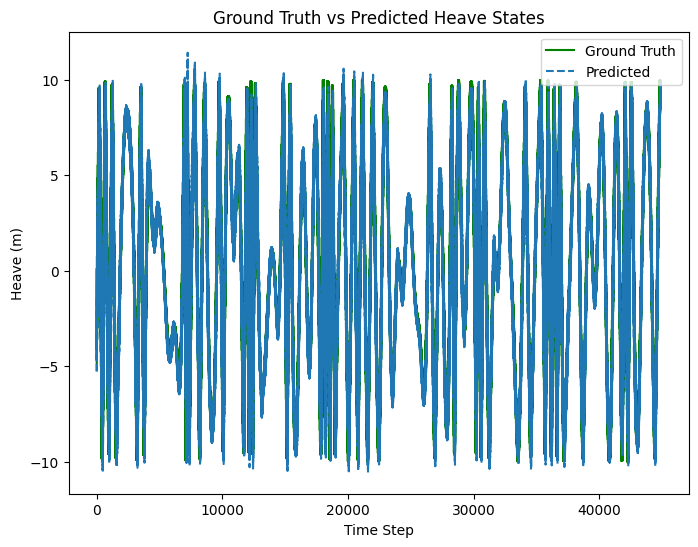

In [ ]:
print(y_val_inverse)
print(y_pred_inverse)

plt.figure(figsize=(8, 6))
plt.plot(y_val_inverse, label='Ground Truth',color='green')
plt.plot(y_pred_inverse, label='Predicted', linestyle='dashed')
plt.xlabel('Time Step')
plt.ylabel('Heave (m)')
plt.title('Ground Truth vs Predicted Heave States')
plt.legend()
plt.show()

### Plots

In [ ]:
# Compare predictions with ground truth

# Plot the first example from the test set for visualization
plt.figure(figsize=(15, 6))
plt.plot(y_test_original_scale[:,0], label='Ground Truth',color='green')
plt.plot(predictions_original_scale[:,0], label='Predicted', linestyle='dashed')
plt.xlabel('Time Step')
plt.ylabel('Heave (m)')
plt.title('Ground Truth vs Predicted Heave States')
plt.legend()
plt.show()

# Calculate Mean Squared Error for evaluation
# from sklearn.metrics import mean_squared_error

# mse = mean_squared_error(y_test_original_scale, predictions_original_scale)
# print(f'Mean Squared Error: {mse}')

NameError: name 'y_test_original_scale' is not defined

<Figure size 1500x600 with 0 Axes>

In [ ]:
print(predictions_original_scale)
print(y_test_original_scale)
# print(predictions_original_scale[:,0])
# print(y_test_original_scale[:,0])
print(predictions.shape)
print(predictions_original_scale.shape)
print(y_test_original_scale.shape)

# Model Testing on D1H5

141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step
-----------------------
-------Metrics---------
-----------------------
Max Error: 1545.74625 cm
Min Error: -1422.8200000000002 cm
Median Error: -5.803750000000019 cm
Mean Squared Error: 13809.983688484914 cm
Mean Absolute Error: 75.33361232709149 cm


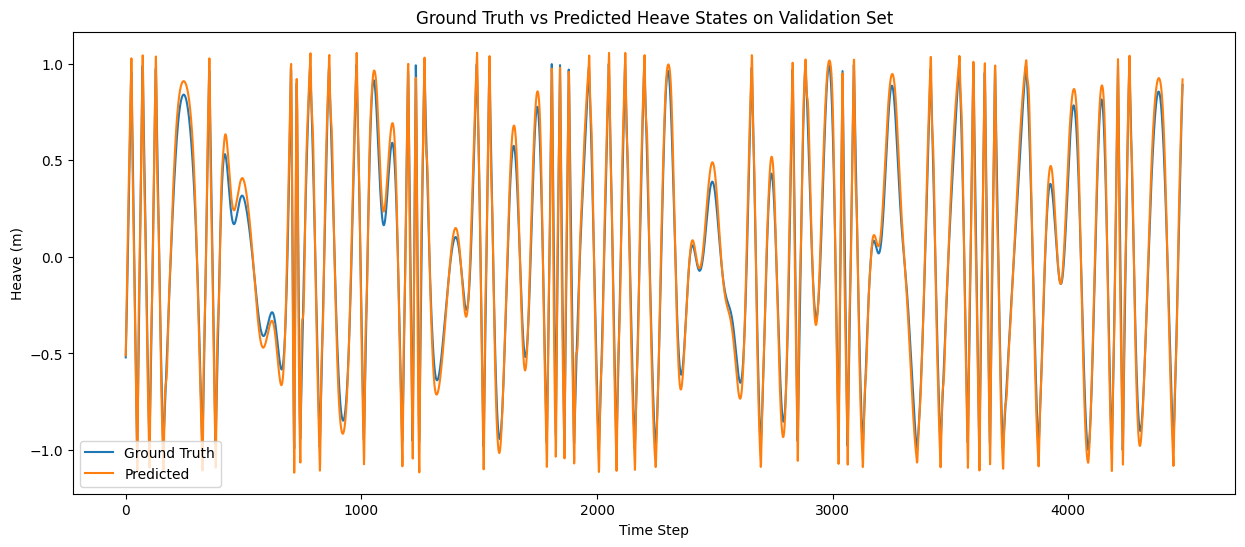

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Load X_val
# X_val = np.load('/content/X_val_d1h4.npy')  # Update the path to your actual file

# Step 2: Load the saved model
model = load_model('/content/model_iteration5.h5')  # Update the path to your actual file

# Step 3: Make predictions on the validation data
y_pred = model.predict(X_val)

# Step 4: Evaluate the model's performance
# Assuming y_val is also loaded or available
# If y_val is stored similarly to X_val, you can load it similarly
# y_val = np.load('/content/y_val.npy')  # Update the path to your actual file
y_val = y_val.reshape(-1,10)
y_pred = y_pred.reshape(-1,10)
# Inverse transform y_val and y_pred
y_val_inverse = scaler_custom.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_pred_inverse = scaler_custom.inverse_transform(y_pred.reshape(-1, 1)).flatten()
# print(y_val_inverse)
# print(y_pred_inverse)

# Calculate Error Metrics
print("-----------------------")
print("-------Metrics---------")
print("-----------------------")

mse = mean_squared_error(y_val_inverse, y_pred_inverse)
mae = mean_absolute_error(y_val_inverse, y_pred_inverse)
diff = y_val_inverse-y_pred_inverse

np.savetxt("y_val_inverse.csv", y_val_inverse, delimiter=",")
np.savetxt("y_pred_inverse.csv", y_pred_inverse, delimiter=",")

print(f'Max Error: {np.max(diff)*100} cm')
print(f'Min Error: {np.min(diff)*100} cm')
print(f'Median Error: {np.median(diff)*100} cm')
print(f'Mean Squared Error: {mse*100*100} cm')
print(f'Mean Absolute Error: {mae*100} cm')

# Plot the first example from the validation set for visualization
plt.figure(figsize=(15, 6))
plt.plot(y_val[:,0], label='Ground Truth')
plt.plot(y_pred[:,0], label='Predicted')
plt.xlabel('Time Step')
plt.ylabel('Heave (m)')
plt.title('Ground Truth vs Predicted Heave States on Validation Set')
plt.legend()
plt.show()

In [ ]:
np.savetxt('y_train_d1h4.csv', y_train.reshape(-1,10))
np.savetxt('y_val_d1h4.csv', y_val.reshape(-1,10))